In [28]:
import torch
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection
from datasets import (
    Dataset,
    Features,
    Value,
    Image as HfImage,
    load_dataset,
    concatenate_datasets,
)
from PIL import Image as PilImage, ImageDraw, ImageFont
import numpy as np
import os
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches

## Load the dataset

In [29]:
base_dir = "../data/Dataset_BUSI_with_GT/"

records = []
for label in ["benign", "malignant", "normal"]:
    folder = os.path.join(base_dir, label)
    for file in os.listdir(folder):
        if not file.endswith(".png") or "mask" in file:
            continue

        img_path = os.path.join(folder, file)

        # Find all masks for this image
        base_name = file.replace(".png", "")
        mask_files = [
            f for f in os.listdir(folder) if f.startswith(base_name + "_mask")
        ]

        if mask_files:
            masks = []
            for m in mask_files:
                mask_img = np.array(PilImage.open(os.path.join(folder, m)).convert("L"))
                masks.append(mask_img > 0)

            merged_mask = np.any(masks, axis=0).astype(np.uint8) * 255
            conditioning_image = PilImage.fromarray(merged_mask)
        else:
            conditioning_image_path = None

        records.append(
            {
                "image": img_path,  # just the path
                "conditioning_image": conditioning_image,  # PIL Image or None
                "caption": label,
            }
        )

# Define features so Hugging Face knows how to decode them
features = Features(
    {"image": HfImage(), "conditioning_image": HfImage(), "caption": Value("string")}
)

kaggle_dataset = Dataset.from_list(records, features=features)

hf = load_dataset("Amss007/ultrasound_dataset_v3_1", cache_dir="../data")

features = Features(
    {"image": HfImage(), "conditioning_image": HfImage(), "caption": Value("string")}
)

# Cast Kaggle dataset
kaggle_dataset = kaggle_dataset.cast(features)

hf_dataset = hf["train"]  # flatten to Dataset
hf_dataset = hf_dataset.cast(features)

merged_dataset = concatenate_datasets([kaggle_dataset, hf_dataset])

print(merged_dataset)

Casting the dataset:   0%|          | 0/780 [00:00<?, ? examples/s]

Dataset({
    features: ['image', 'conditioning_image', 'caption'],
    num_rows: 4765
})


## Load the model, processor, and pipeline

In [30]:
sample = merged_dataset[0]          # take the first example
image = sample["image"]             # PIL Image

# prompts = ["benign", "malignant", "tumor", "only one circular patch", sample['caption']]  # manual prompts
# prompts = ["only one circular patch", sample['caption']]  # Gave better results
prompts = ["only one circular patch which is "+sample['caption']]  # manual prompts

In [31]:

# Set device (GPU if available, else CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Tiny Swin-T checkpoint trained on O365+GoldG+GRIT+V3Det
# model_id = "openmmlab-community/mm_grounding_dino_tiny_o365v1_goldg_grit_v3det"
# model_id = "openmmlab-community/mm_grounding_dino_tiny_o365v1_goldg_v3det"
model_id = "IDEA-Research/grounding-dino-tiny"

# This handles all preprocessing for images + text
processor = AutoProcessor.from_pretrained(model_id, use_fast=False)

# This is the object detection model that predicts bounding boxes and labels
model = AutoModelForZeroShotObjectDetection.from_pretrained(model_id).to(device)

# Preprocess image + text
inputs = processor(
    images=image,
    text=prompts,
    return_tensors="pt"
)

# Forward pass
with torch.no_grad():
    outputs = model(**inputs)

# Inspect outputs
print(outputs.keys())

Using device: cpu


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

odict_keys(['logits', 'pred_boxes', 'last_hidden_state', 'init_reference_points', 'intermediate_hidden_states', 'intermediate_reference_points', 'encoder_last_hidden_state_vision', 'encoder_last_hidden_state_text', 'enc_outputs_class', 'enc_outputs_coord_logits', 'encoder_logits', 'encoder_pred_boxes', 'input_ids'])


In [32]:
def visualize_detections_matplotlib(image, detections):
    fig, ax = plt.subplots(1, figsize=(12, 8))
    ax.imshow(image)
    
    # Color map for different labels
    colors = plt.cm.tab10(np.linspace(0, 1, 10))
    label_to_color = {}
    
    for i, det in enumerate(detections):
        box = det["box"]  # [x_min, y_min, x_max, y_max]
        label = det["label"]
        score = det["score"]
        
        # Assign color
        if label not in label_to_color:
            label_to_color[label] = colors[len(label_to_color) % 10]
        color = label_to_color[label]
        
        # Draw bounding box
        x_min, y_min, x_max, y_max = box
        width = x_max - x_min
        height = y_max - y_min
        
        rect = patches.Rectangle(
            (x_min, y_min), width, height,
            linewidth=3, edgecolor=color, facecolor='none'
        )
        ax.add_patch(rect)
        
        # Add label text
        label_text = f"{label}: {score:.2f}"
        ax.text(
            x_min, y_min - 5,
            label_text,
            bbox=dict(boxstyle='round,pad=0.5', facecolor=color, alpha=0.7),
            fontsize=10, color='white', weight='bold'
        )
    
    ax.axis('off')
    plt.tight_layout()
    plt.show()

In [33]:
# Post-process
results = processor.post_process_grounded_object_detection(
    outputs,
    inputs.input_ids,
    target_sizes=[image.size[::-1]]
)

# Now filter by thresholds manually
threshold = 0.3  # Adjust as needed

post_labels = results[0]["labels"]
post_scores = results[0]["scores"]
post_boxes = results[0]["boxes"]

filtered_detections = []
for label, score, box in zip(post_labels, post_scores, post_boxes):
    if score >= threshold:
        filtered_detections.append({
            "label": label,
            "score": score.item(),
            "box": box.tolist()
        })
        print(f"Detected: {label} with confidence {score:.2f}")

# Use the visualization methods
print(f"\nTotal detections above threshold: {len(filtered_detections)}")

# # Visualize with matplotlib
# visualize_detections_matplotlib(image, filtered_detections)

Detected: one circular patch with confidence 0.43

Total detections above threshold: 1


In [34]:
pred_logits = outputs.logits       # [1, num_queries, num_classes]
pred_boxes  = outputs.pred_boxes   # [1, num_queries, 4], normalized

threshold = 0.3
probs = pred_logits.softmax(-1)[0, :, :-1]  # ignore last "no-object" class
scores, labels = probs.max(-1)              # max probability per query
mask = scores > threshold

filtered_boxes  = pred_boxes[0][mask]
filtered_scores = scores[mask]
filtered_labels = labels[mask]

# Convert normalized boxes to pixel coordinates
width, height = image.size
boxes_corner = filtered_boxes.clone()
boxes_corner[:, 0] = (filtered_boxes[:, 0] - filtered_boxes[:, 2] / 2) * width   # x1
boxes_corner[:, 1] = (filtered_boxes[:, 1] - filtered_boxes[:, 3] / 2) * height  # y1
boxes_corner[:, 2] = (filtered_boxes[:, 0] + filtered_boxes[:, 2] / 2) * width   # x2
boxes_corner[:, 3] = (filtered_boxes[:, 1] + filtered_boxes[:, 3] / 2) * height  # y2


# Print results
for box, score, label in zip(boxes_corner, filtered_scores, filtered_labels):
    x1, y1, x2, y2 = box.tolist()
    print(f"Detected class {label.item()} with score {score.item():.2f} at [{x1:.1f}, {y1:.1f}, {x2:.1f}, {y2:.1f}]")

Detected class 7 with score 0.34 at [310.7, 89.8, 453.4, 206.3]
Detected class 7 with score 0.33 at [101.7, 84.3, 313.6, 209.4]
Detected class 7 with score 0.32 at [307.1, 118.1, 457.9, 167.6]


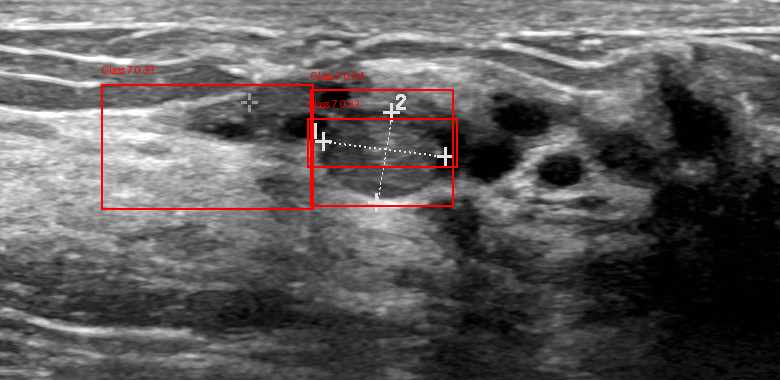

In [35]:
draw_image = image.copy()
draw = ImageDraw.Draw(draw_image)

try:
    font = ImageFont.truetype("arial.ttf", 16)
except:
    font = ImageFont.load_default()

for box, score, label in zip(boxes_corner, filtered_scores, filtered_labels):
    x1, y1, x2, y2 = box.tolist()
    
    draw.rectangle([x1, y1, x2, y2], outline="red", width=2)
    draw.text((x1, max(y1 - 20, 0)), f"Class {label.item()} {score.item():.2f}", 
              fill="red", font=font)

draw_image

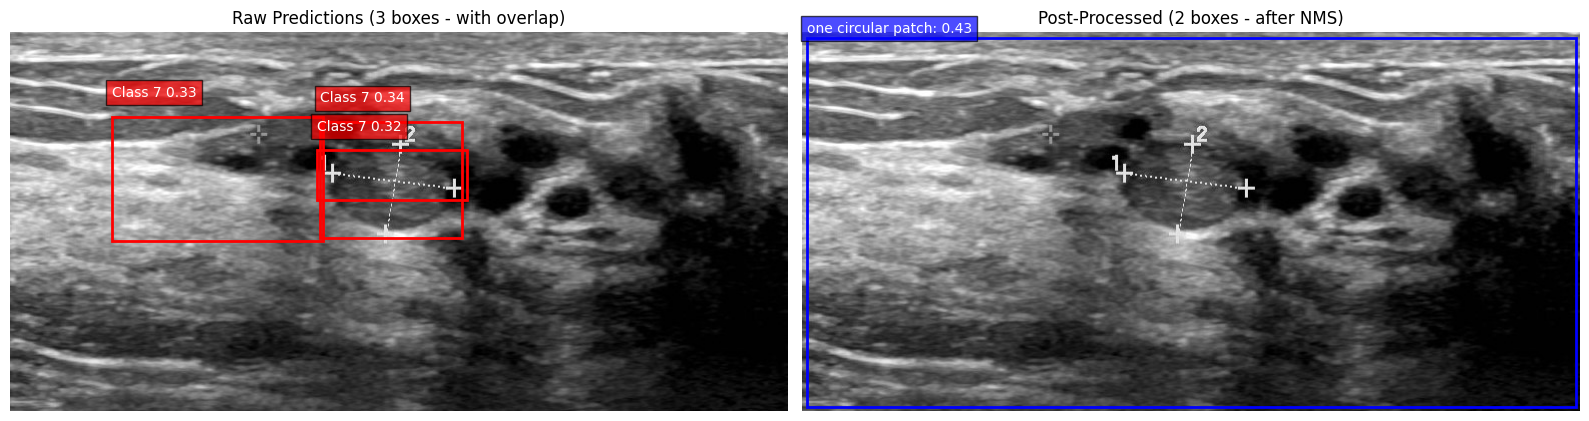

In [38]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Show raw detections (3 boxes)
ax1.imshow(image)
ax1.set_title("Raw Predictions (3 boxes - with overlap)")
for box, label, score in zip(filtered_boxes, filtered_labels, filtered_scores):
    cx, cy, w, h = box.tolist()
    x1 = (cx - w/2) * width
    y1 = (cy - h/2) * height
    rect = patches.Rectangle(
        (x1, y1), w*width, h*height,
        linewidth=2, edgecolor='red', facecolor='none'
    )
    ax1.add_patch(rect)
    ax1.text(x1, max(y1 - 20, 0), f"Class {label.item()} {score.item():.2f}", 
              color="white", bbox=dict(facecolor='red', alpha=0.7))
ax1.axis('off')

# Show post-processed results (2 boxes)
ax2.imshow(image)
ax2.set_title("Post-Processed (2 boxes - after NMS)")
for box, label, score in zip(post_boxes, post_labels, post_scores):
    if score >= 0.3:
        x1, y1, x2, y2 = box.tolist()
        rect = patches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            linewidth=2, edgecolor='blue', facecolor='none'
        )
        ax2.add_patch(rect)
        ax2.text(x1, y1-5, f"{label}: {score:.2f}", 
                color='white', bbox=dict(facecolor='blue', alpha=0.7))
ax2.axis('off')

plt.tight_layout()
plt.show()
